Read sales.csv data and do the following exercises:


In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import random
import seaborn as sns
import ast
# import ast
from collections import Counter

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Displaying all columns in jupyter output
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('sales.csv')
df.head(12)

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


In [4]:
display(df.describe())
display(df.info())

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000,12.000000
mean,6.500000,2873.333333,1542.916667,5825.833333,9500.833333,2117.500000,1542.916667,26027.50000,260275.000000
std,3.605551,584.595172,316.733745,1242.032486,2348.095779,617.724931,316.733745,7014.36594,70143.659404
min,1.000000,1990.000000,1120.000000,4550.000000,6100.000000,1200.000000,1120.000000,18330.00000,183300.000000
25%,3.750000,2460.000000,1305.000000,4862.500000,8015.000000,1795.000000,1305.000000,21065.00000,210650.000000
50%,6.500000,2830.000000,1527.500000,5530.000000,9090.000000,1995.000000,1527.500000,22935.00000,229350.000000
75%,9.250000,3435.000000,1765.000000,6400.000000,10045.000000,2325.000000,1765.000000,29667.50000,296675.000000
max,12.000000,3700.000000,2100.000000,8300.000000,14400.000000,3550.000000,2100.000000,41280.00000,412800.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   month_number  12 non-null     int64
 1   facecream     12 non-null     int64
 2   facewash      12 non-null     int64
 3   toothpaste    12 non-null     int64
 4   bathingsoap   12 non-null     int64
 5   shampoo       12 non-null     int64
 6   moisturizer   12 non-null     int64
 7   total_units   12 non-null     int64
 8   total_profit  12 non-null     int64
dtypes: int64(9)
memory usage: 992.0 bytes


None

# Exercise 1:<br/> 
Read Total profit of all months and show it using a line plot
Total profit data provided for each month.<br/>
Generated line plot must include the following properties:

X label name = Month Number<br/>
Y label name = Total profit<br/>
The line plot graph should look like this.<br/>

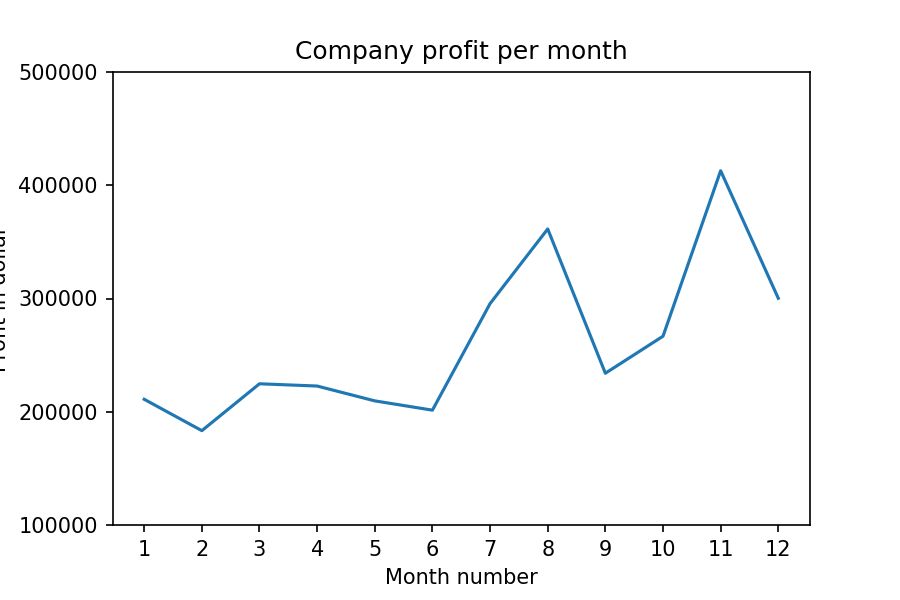


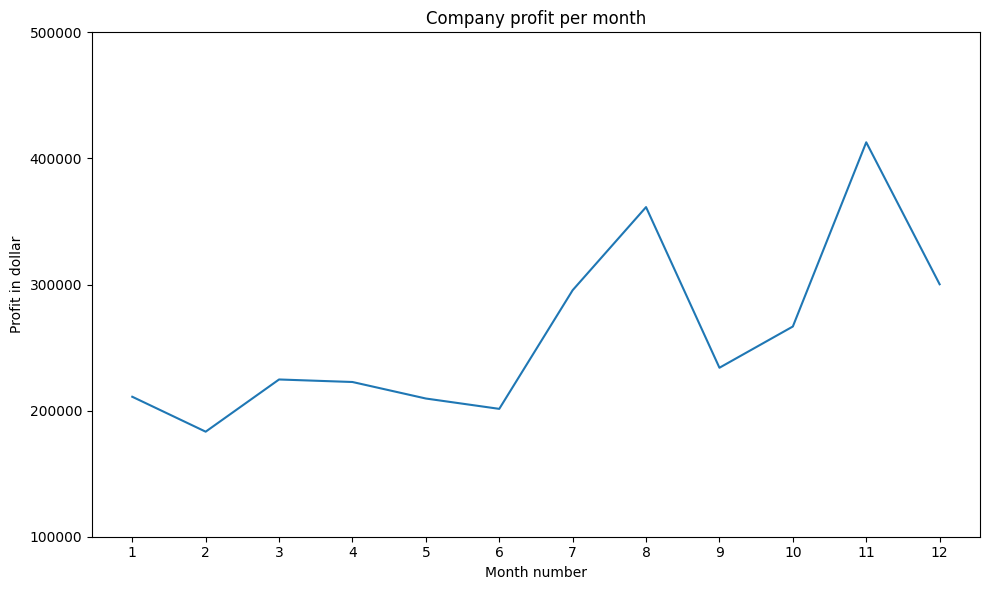

In [5]:
# Plot the line graph
plt.figure(figsize=(10, 6))  # Adjust figure size
plt.plot(df['month_number'], df['total_profit'], linestyle='-', linewidth=1.5)

# Add labels to the axes
plt.xlabel('Month number')
plt.ylabel('Profit in dollar')

# Add a title to the plot
plt.title('Company profit per month')

# Dynamically adjust y-axis to ensure limits align with exact edges
ylim = plt.gca().get_ylim()
lower_limit = int(ylim[0] // 100000) * 100000  # Round down to the nearest 100000
upper_limit = int(ylim[1] // 100000 + 1) * 100000  # Round up to the nearest 100000
plt.ylim(lower_limit, upper_limit)

# Set y-axis ticks to show only complete numbers (multiples of 100000)
plt.yticks(range(lower_limit, upper_limit + 100000, 100000))

# Dynamically adjust x-axis to show all month numbers
plt.xticks(range(1, len(df['month_number']) + 1))

plt.tight_layout()  # Ensure everything fits perfectly

# Display the plot
plt.show()


# Exercise 2:<br/>
Get total profit of all months and show line plot with the following Style properties
Generated line plot must include following Style properties:

Line Style dotted and Line-color should be red<br/>
Show legend at the lower right location.<br/>
X label name = Month Number<br/>
Y label name = Sold units number<br/>
Add a circle marker.<br/>
Line marker color as read<br/>
Line width should be 3<br/>
The line plot graph should look like this.<br/>

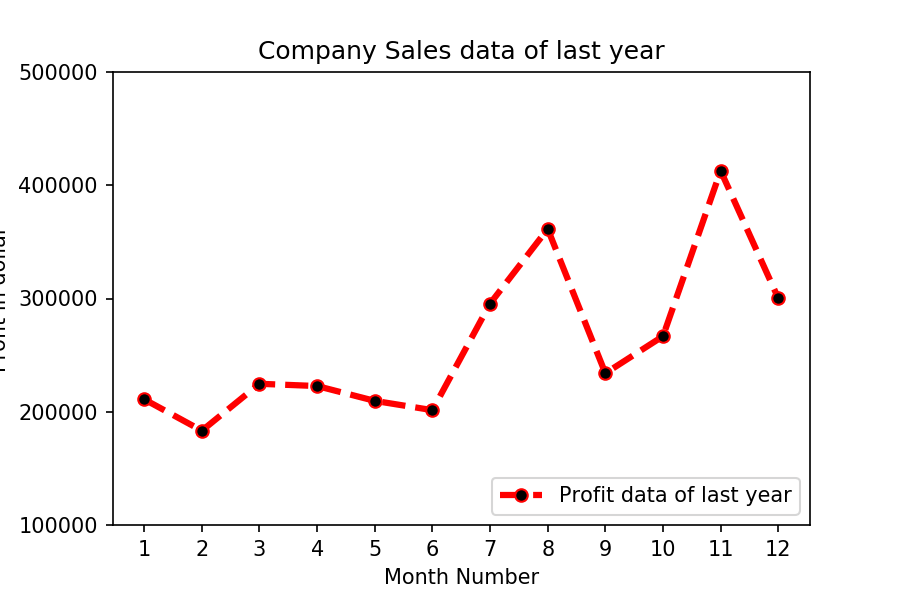


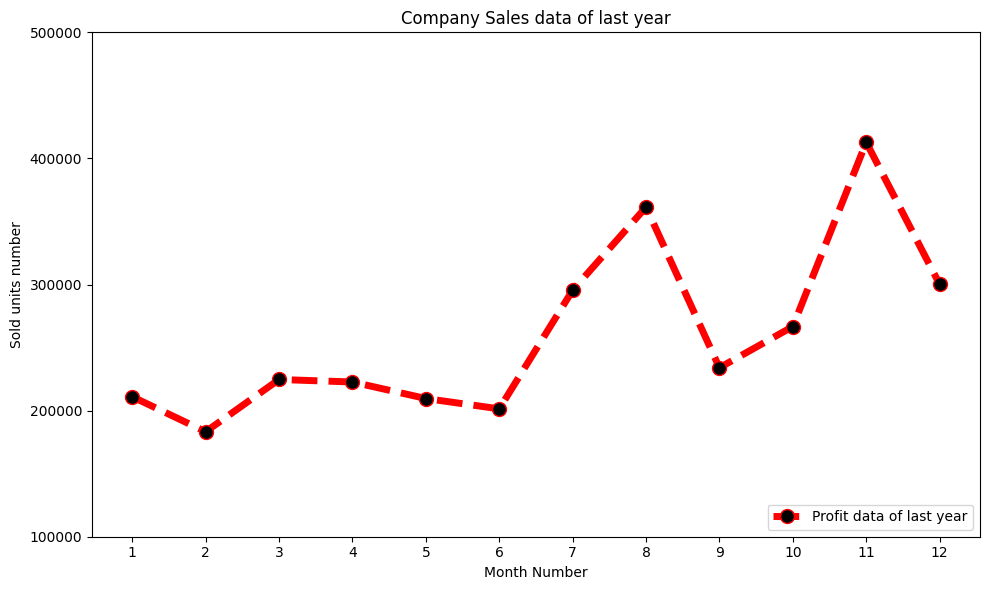

In [6]:
# Plot the line graph with the required style
plt.figure(figsize=(10, 6))  # Adjust figure size
plt.plot(
    df['month_number'], 
    df['total_profit'], 
    linestyle='--',  # Dotted line style
    color='red',     # Line color
    marker='o',      # Circle marker
    markerfacecolor='black',  # Marker color
    markersize=10,   # Size of the circle markers
    linewidth=5,     # Line width
    label='Profit data of last year'  # Legend label
)

# Add labels to the axes
plt.xlabel('Month Number')
plt.ylabel('Sold units number')

# Add a title to the plot
plt.title('Company Sales data of last year')

# Dynamically adjust y-axis to ensure limits align with exact edges
ylim = plt.gca().get_ylim()
lower_limit = int(ylim[0] // 100000) * 100000  # Round down to the nearest 100000
upper_limit = int(ylim[1] // 100000 + 1) * 100000  # Round up to the nearest 100000
plt.ylim(lower_limit, upper_limit)

# Set y-axis ticks to show only complete numbers (multiples of 100000)
plt.yticks(range(lower_limit, upper_limit + 100000, 100000))

# Dynamically adjust x-axis to show all month numbers
plt.xticks(range(1, len(df['month_number']) + 1))

plt.tight_layout()  # Ensure everything fits perfectly

# Show legend at the lower right location
plt.legend(loc='lower right')

# Display the plot
plt.show()


# Exercise 3:<br/>
Read all product sales data and show it using a multiline plot<br/>
Display the number of units sold per month for each product using multiline plots. (i.e., Separate Plotline for each product ).<br/>

The graph should look like this.<br/>

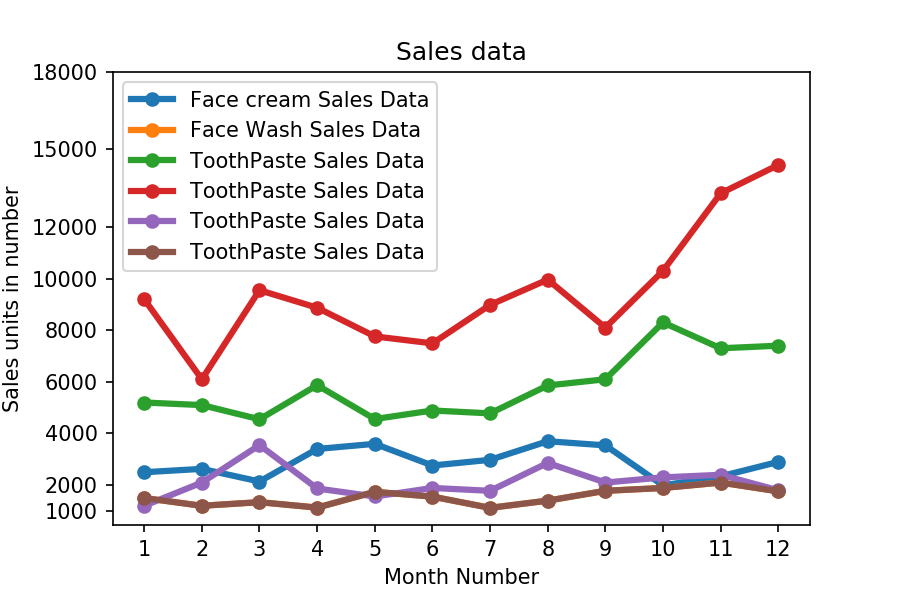


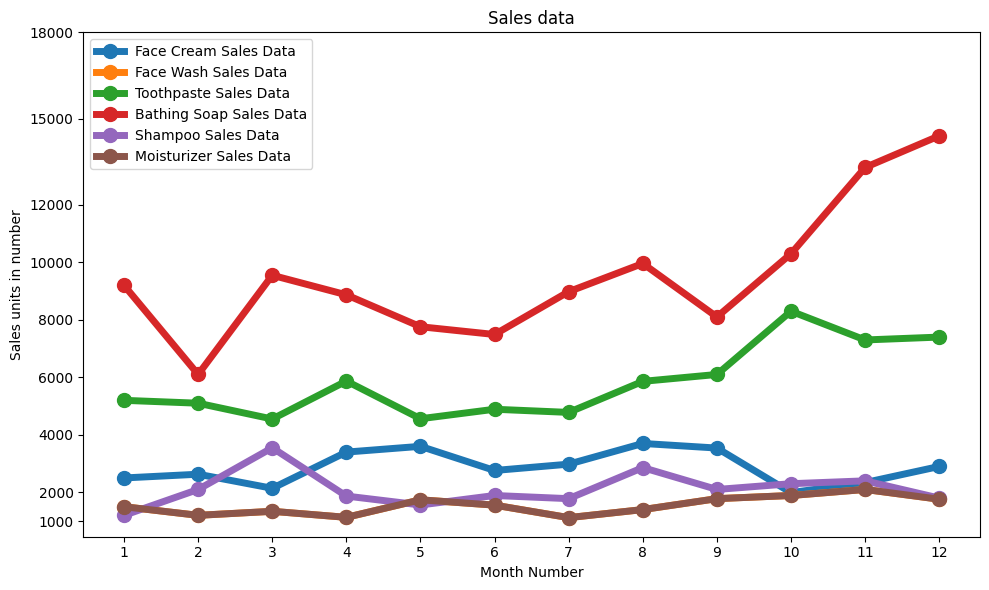

In [7]:
# Plot the multiline graph
plt.figure(figsize=(10, 6))

# Plot each product's sales data
plt.plot(df['month_number'], df['facecream'], label='Face Cream Sales Data', marker='o', linewidth=5, markersize=10)
plt.plot(df['month_number'], df['facewash'], label='Face Wash Sales Data', marker='o', linewidth=5, markersize=10)
plt.plot(df['month_number'], df['toothpaste'], label='Toothpaste Sales Data', marker='o', linewidth=5, markersize=10)
plt.plot(df['month_number'], df['bathingsoap'], label='Bathing Soap Sales Data', marker='o', linewidth=5, markersize=10)
plt.plot(df['month_number'], df['shampoo'], label='Shampoo Sales Data', marker='o', linewidth=5, markersize=10)
plt.plot(df['month_number'], df['moisturizer'], label='Moisturizer Sales Data', marker='o', linewidth=5, markersize=10)

# Add labels and title
plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.title('Sales data')

# Add x-axis ticks for all months
plt.xticks(df['month_number'])

# Set y-axis ticks to match the desired scale
# plt.yticks(range(0, 18001, 1000))  # Adjust range and step to match the image
plt.yticks([1000, 2000, 4000, 6000, 8000, 10000, 12000, 15000, 18000])

# Show legend
plt.legend(loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()


# Exercise 4:<br/>
Read toothpaste sales data of each month and show it using a scatter plot<br/>
Also, add a grid in the plot. gridline style should “–“.<br/>

The scatter plot should look like this.<br/>

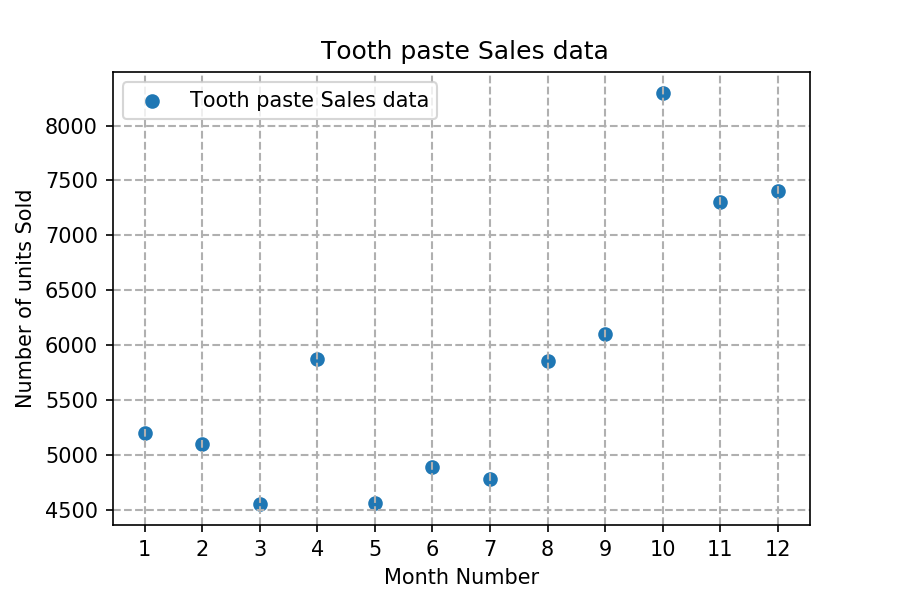


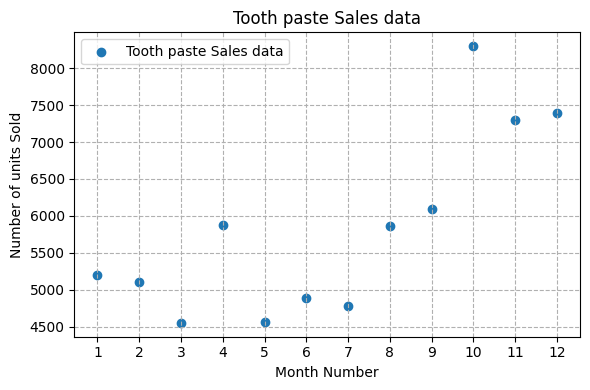

In [8]:
# Create scatter plot for toothpaste sales data
plt.figure(figsize=(6, 4))
plt.scatter(df['month_number'], df['toothpaste'], label='Tooth paste Sales data')

# Add grid with specific style
plt.grid(linestyle='--')

# Add labels and title
plt.xlabel('Month Number')
plt.ylabel('Number of units Sold')
plt.title('Tooth paste Sales data')

# Add x-axis ticks for all months
plt.xticks(df['month_number'])

# Show legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


# Exercise 5:<br/>
Read face cream and facewash product sales data and show it using the bar chart<br/>
The bar chart should display the number of units sold per month for each product. Add a separate bar for each product in the same chart.<br/>

The bar chart should look like this.<br/>

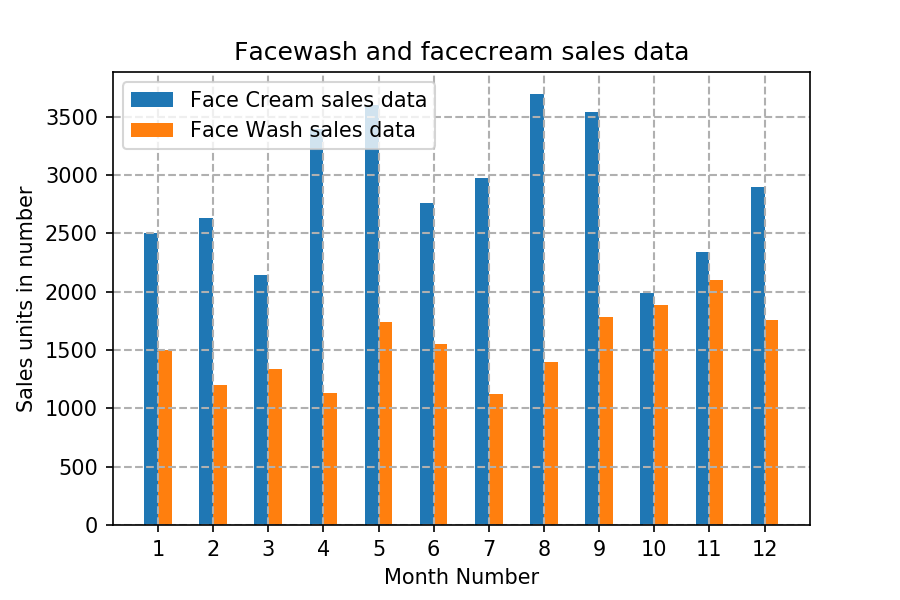


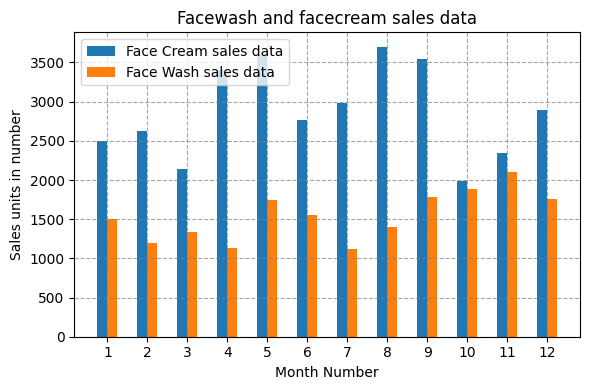

In [9]:
# Bar width for each product
bar_width = 0.25

# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(df['month_number'] - bar_width / 2, df['facecream'], width=bar_width, label='Face Cream sales data', color='#1f77b4')
plt.bar(df['month_number'] + bar_width / 2, df['facewash'], width=bar_width, label='Face Wash sales data', color='#ff7f0e')

# Add gridlines for both horizontal and vertical axes
plt.grid(linestyle='--', axis='y', color='gray', alpha=0.7)
plt.grid(linestyle='--', axis='x', color='gray', alpha=0.7)

# Add labels and title
plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.title('Facewash and facecream sales data')

# Add x-axis ticks for all months
plt.xticks(df['month_number'])

# Show legend
plt.legend(loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()


# Exercise 6:<br/>
Read sales data of bathing soap of all months and show it using a bar chart. Save this plot to your hard disk<br/>
The bar chart should look like this.<br/>

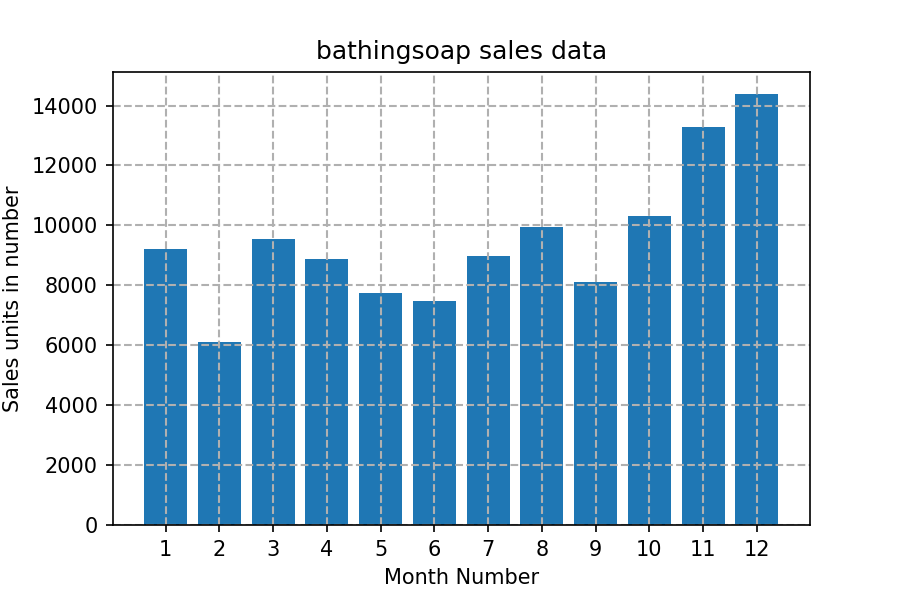


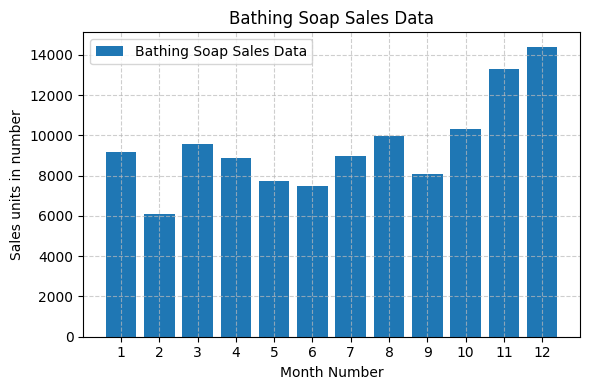

In [10]:
# Create bar chart for bathing soap sales data
plt.figure(figsize=(6, 4))
plt.bar(df['month_number'], df['bathingsoap'], color='#1f77b4', label='Bathing Soap Sales Data')

# Add gridlines for better readability
plt.grid(linestyle='--', color='#BABABA', alpha=0.7)

# Add labels and title
plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.title('Bathing Soap Sales Data')

# Add x-axis ticks for all months
plt.xticks(df['month_number'])

# Show legend
plt.legend()

# Save the plot to hard disk
plt.tight_layout()
plt.savefig('bathingsoap_sales_chart.png')  # Save the chart as a PNG file

# Display the plot
plt.show()


# Exercise 7:<br/>
Read the total profit of each month and show it using the histogram to see the most common profit ranges<br/>
The histogram should look like this.<br/>

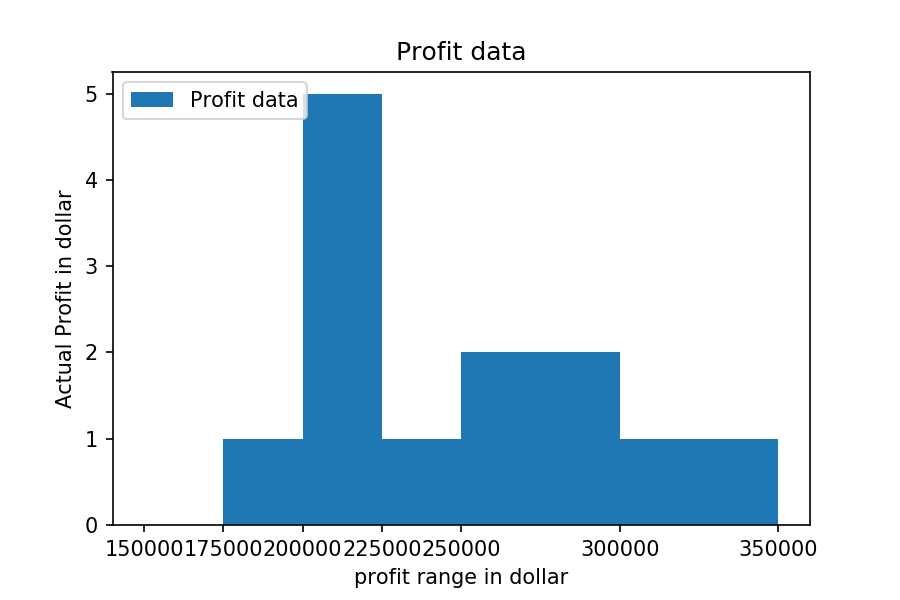


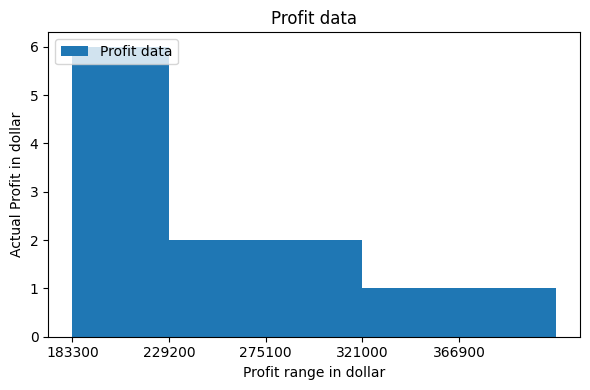

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data from your CSV file (replace 'sales.csv' with your actual file name)
df = pd.read_csv('sales.csv')

# Create the histogram data
plt.figure(figsize=(6, 4))
counts, bins, _ = plt.hist(df['total_profit'], bins=5, color='#1f77b4', label='Profit data')

# Add labels and title
plt.xlabel('Profit range in dollar')
plt.ylabel('Actual Profit in dollar')
plt.title('Profit data')

# Adjust x-axis ticks based on bins where Y changes
x_ticks = bins[:-1]  # Use the left edges of bins as ticks
plt.xticks(x_ticks, labels=[f'{int(x)}' for x in x_ticks])

# Add legend
plt.legend(loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()


# Exercise 8:<br/>
Calculate total sale data for last year for each product and show it using a Pie chart<br/>
Note: In Pie chart display Number of units sold per year for each product in percentage.<br/>

The Pie chart should look like this.<br/>

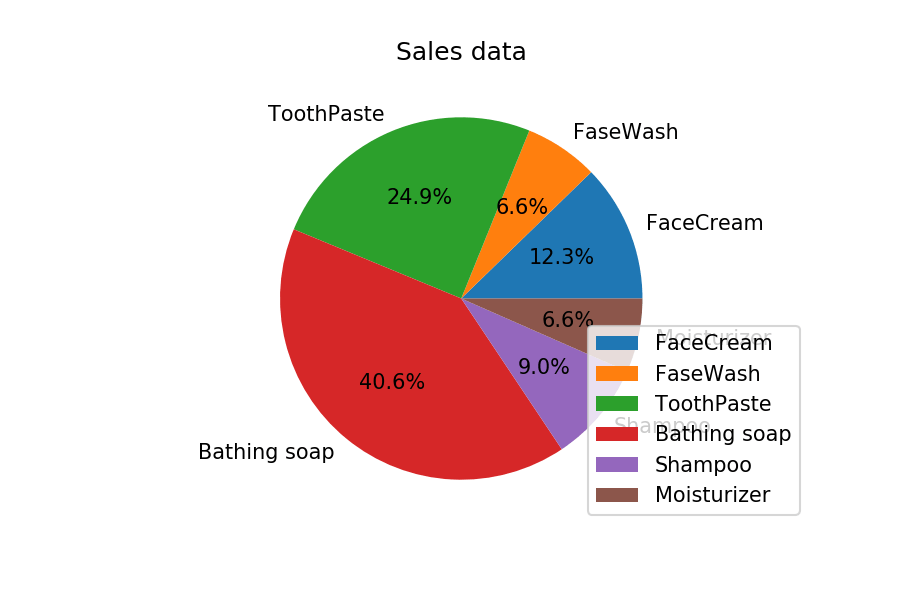


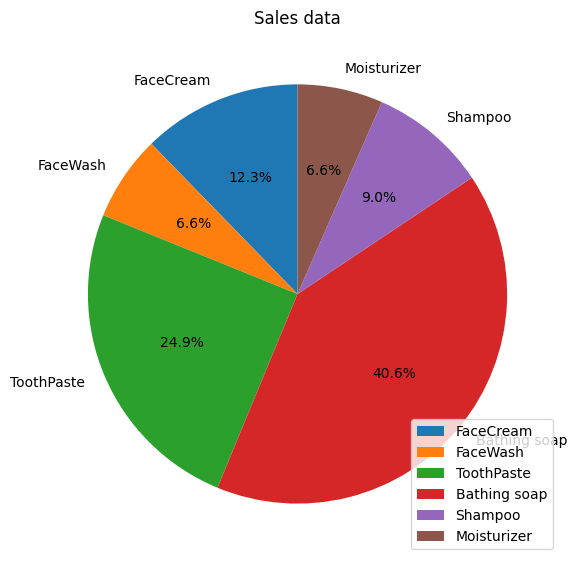

In [12]:
# Calculate total sales for each product
product_sales = {
    'FaceCream': df['facecream'].sum(),
    'FaceWash': df['facewash'].sum(),
    'ToothPaste': df['toothpaste'].sum(),
    'Bathing soap': df['bathingsoap'].sum(),
    'Shampoo': df['shampoo'].sum(),
    'Moisturizer': df['moisturizer'].sum()
}

# Convert to DataFrame for easier management
sales_df = pd.DataFrame(product_sales.items(), columns=['Product', 'Total Sales'])

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sales_df['Total Sales'],
    labels=sales_df['Product'],
    autopct='%1.1f%%',  # Display percentages with one decimal place
    colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],  # Define colors for the slices
    startangle=90  # Start the chart at the top
)

# Add title
plt.title('Sales data')

# Add legend
plt.legend(sales_df['Product'], loc='lower right')

# Display the chart
plt.tight_layout()
plt.show()


# Exercise 9:<br/>
Read Bathing soap facewash of all months and display it using the Subplot<br/>
The Subplot should look like this.<br/>

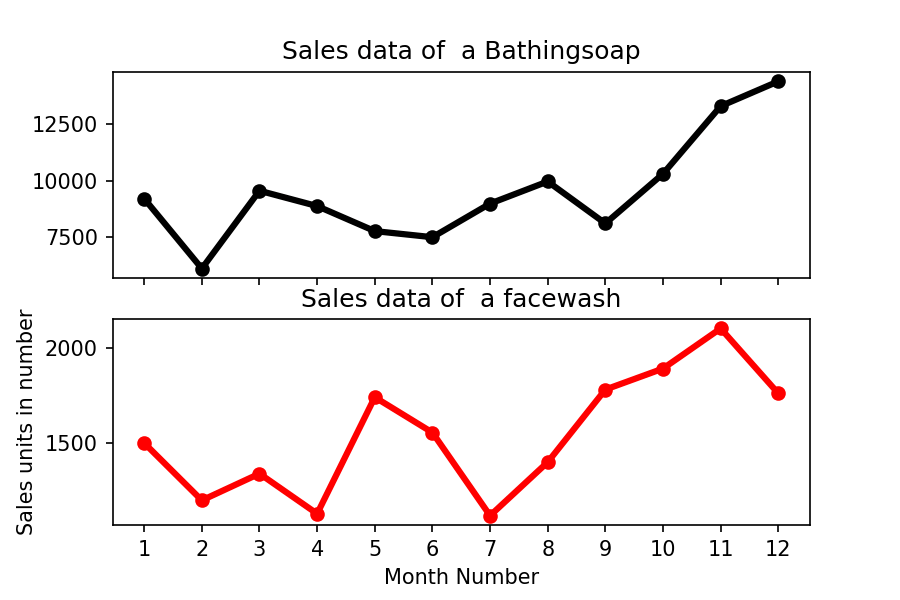


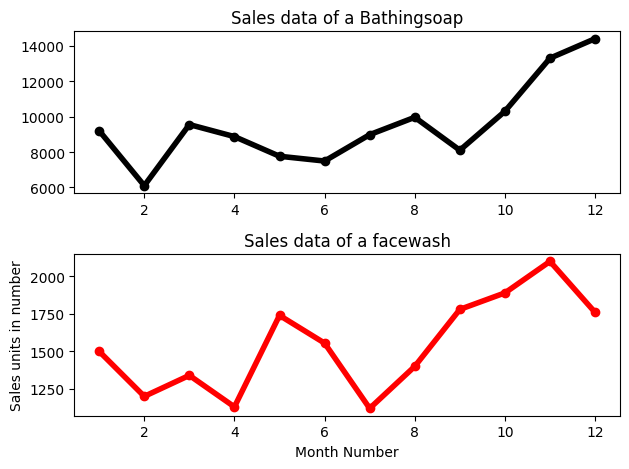

In [13]:
# First Subplot: Bathing Soap
plt.subplot(2, 1, 1)  # 2 rows, 1 column, position 1
plt.plot(df['month_number'], df['bathingsoap'], color='black', marker='o', linewidth=4, markersize=6)  # Black line with circle markers
plt.title('Sales data of a Bathingsoap')  # Title for the subplot

# Second Subplot: Face Wash
plt.subplot(2, 1, 2)  # 2 rows, 1 column, position 2
plt.plot(df['month_number'], df['facewash'], color='red', marker='o', linewidth=4, markersize=6)  # Red line with circle markers
plt.title('Sales data of a facewash')  # Title for the subplot
plt.xlabel('Month Number')  # Label for the x-axis
plt.ylabel('Sales units in number')  # Label for the y-axis

# Adjust the spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()


# Exercise 10:<br/>
Read all product sales data and show it using the stack plot<br/>
The Stack plot should look like this.<br/>

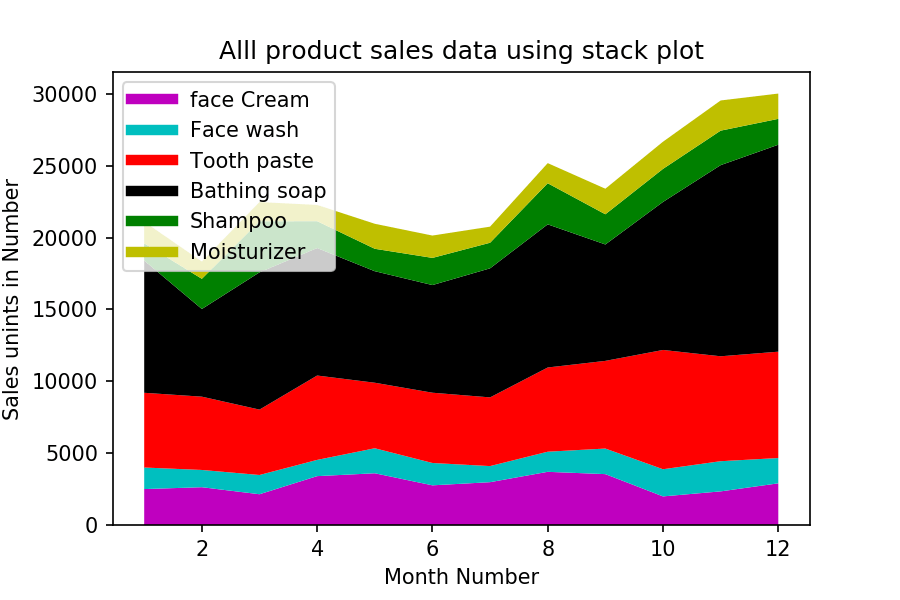


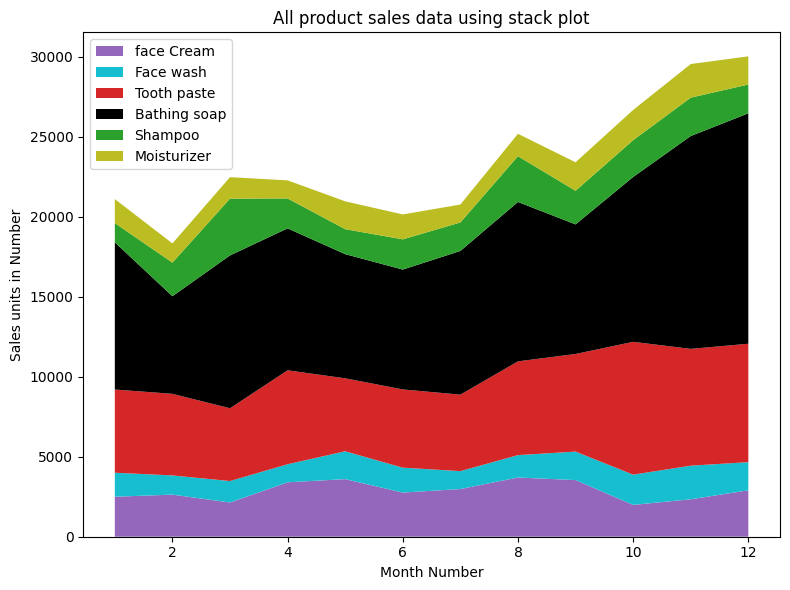

In [14]:
# Data for each product
products = ['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo', 'moisturizer']
colors = ['#9467bd', '#17becf', '#d62728', '#000000', '#2ca02c', '#bcbd22']  # Colors for each product

# Plot the stack plot
plt.figure(figsize=(8, 6))  # Set the figure size
plt.stackplot(
    df['month_number'],  # X-axis data: Month numbers
    [df[product] for product in products],  # Y-axis data: Sales data for all products
    labels=['face Cream', 'Face wash', 'Tooth paste', 'Bathing soap', 'Shampoo', 'Moisturizer'],  # Labels for each product
    colors=colors  # Use predefined colors for the products
)

# Add labels and title
plt.title('All product sales data using stack plot')  # Title for the plot
plt.xlabel('Month Number')  # Label for the x-axis
plt.ylabel('Sales units in Number')  # Label for the y-axis

# Add legend
plt.legend(loc='upper left')  # Place the legend in the upper left corner

# Display the plot
plt.tight_layout()  # Adjust layout for better spacing
plt.show()
